# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Grace Ketchum
* Username: gbketchum
* Student number: S6230024
* Group (AS1, etc.): AS1
-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

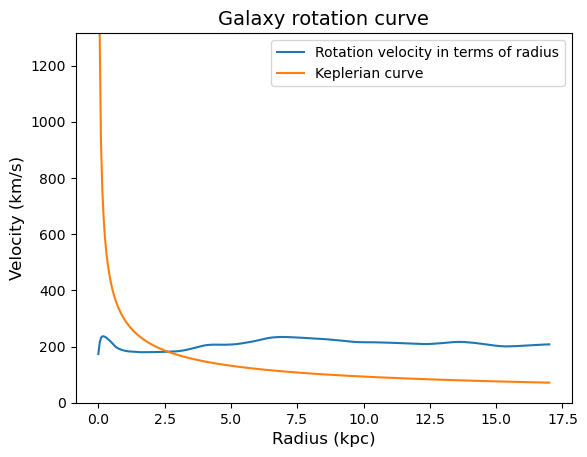

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

data = np.loadtxt('rotcur.dat.txt', comments="#")
R= data[:,0]; V= data[:,1] #taking first and second columns 

Ms=2*(10**30) #defining the solar mass
M=2*(10**10)*Ms #calculating the mass in kg

R2=R[1:] #making it so that there's no division by zeroes

R3=R2*3.086e19 #converting the kpc to m 

v=(((G*M)/R3)**(1/2))/1000 #making the velocity in km/s

np.savetxt('keplerian_curve.txt', v)

kep=np.loadtxt('keplerian_curve.txt') #loading the keplarian curve

max_k=np.max(kep) #defining the max values of the keplarian curve

plt.plot(R, V, label='Rotation velocity in terms of radius')#creating a line plot where R is the x axis and V is the y axis
plt.plot(R2, kep, label='Keplerian curve') #making teh plot of the keplarian curve 
plt.ylim(0, max_k) #forcing the y axis range 
plt.legend()
plt.xlabel('Radius (kpc)', fontsize= 12)
plt.ylabel('Velocity (km/s)', fontsize=12)
plt.title('Galaxy rotation curve', fontsize=14)
plt.show()
#The keplerian curve falls of at 1/sqrt(r)

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

The mean of the 30x30 slice is -0.009286862641909468, and the standard deviation is 0.955390793172936
We can recognize a normal distribution


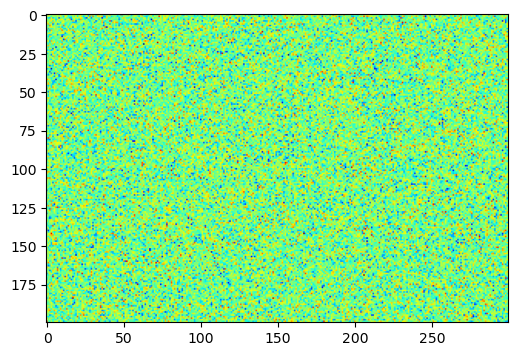

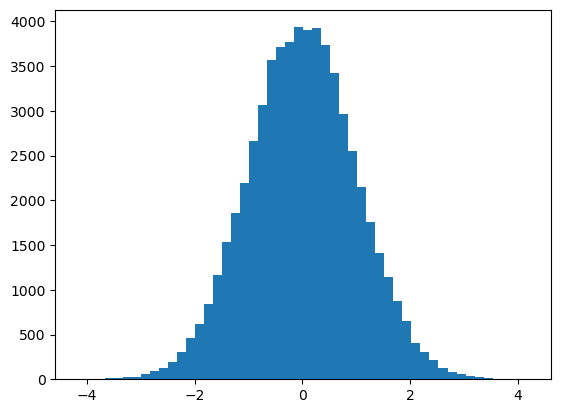

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Arr1 = np.random.normal(0, 1.0, 200*300 ).reshape(200, 300)

Arr2=Arr1[0:30,0:30] #using pixels ranging from 0 to 30 in the rows and in the columns giving a 30x30 slice

mean=np.mean(Arr2) #equal to almost 0
std=np.std(Arr2) #equal to almost 1

print(f"The mean of the 30x30 slice is {mean}, and the standard deviation is {std}")

plt.figure(figsize=(8, 4)) #making the figure 8x4 inches
plt.imshow(Arr1, cmap='jet')

Arr3=Arr1.flatten()
plt.figure()
plt.hist(Arr3, 50)

print("We can recognize a normal distribution")

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

The area of the ellipse is 18.84955592153876 and the perimeter is 15.865437575563961
Ellipse center:0,0, Semi major axis:3, Semi minor axis:2, Position angle:30


(-20.0, 20.0)

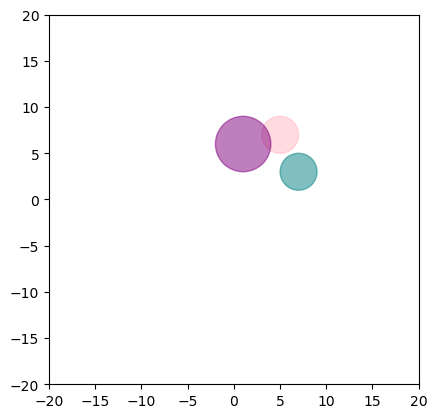

In [3]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import math #importing math
import numpy as np

fig, ax=plt.subplots()

class AstroEllipse(Ellipse):
    
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees  
        
        self.semi_major = semi_major #making the attributes callable in other methods of the class
        self.semi_minor = semi_minor
        self.position_angle=position_angle
        self.xc=xc
        self.yc=yc

        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)

        
    def area(self): #defining the area 
        pi=math.pi
        A= (self.semi_major*self.semi_minor)*pi #using the general formula for the area of an ellipse
        return A
        
    def perimeter(self):#defining the perimeter and using Ramanujan's formula
       pi=math.pi
       P= pi*((3*(self.semi_major+self.semi_minor))-((3*self.semi_major+self.semi_minor)*(self.semi_major+3*self.semi_minor))**(1/2))
       return P

    def __str__(self):#defining teh string method
        s=f"Ellipse center:{self.xc},{self.yc}, Semi major axis:{self.semi_major}, Semi minor axis:{self.semi_minor}, Position angle:{self.position_angle}"
        return s

#creating the example ellipse
ex_ellipse=AstroEllipse(0, 0, semi_major=3, semi_minor=2, position_angle=30)

areaex=ex_ellipse.area() #calling on the area and perimeter methods
periex=ex_ellipse.perimeter()

print(f"The area of the ellipse is {areaex} and the perimeter is {periex}")

stringex=ex_ellipse.__str__() #calling the string method
print(stringex)


class MyCircle(AstroEllipse): #creating the MyCircle class inheriting from AstroEllipse

    def __init__(self, XY, radius, **args): #defining the attributes
        (xc, yc)=XY #translating it from Astroellipse
        semi_major=radius
        semi_minor=radius
        position_angle=0
        super().__init__(xc, yc, semi_major, semi_minor, position_angle, **args)

rad1=np.random.randint(2,10) #using random values for the circles 
rad2=np.random.randint(2,10)
rad3=np.random.randint(2,10)

o1=(np.random.randint(10),np.random.randint(10))
o2=(np.random.randint(10),np.random.randint(10))
o3=(np.random.randint(10),np.random.randint(10))

circle1=MyCircle(o1, rad1, alpha=0.5, color='teal') #calling the class
circle2=MyCircle(o2, rad2, alpha=0.5, color='lightpink')
circle3=MyCircle(o3, rad3, alpha=0.5, color='purple')

ax.set_aspect("equal") #using ax to ensure that they're circles

ax.add_patch(circle1) #using ax to plot the circles
ax.add_patch(circle2)
ax.add_patch(circle3)


ax.set_xlim(-20, 20)#setting the limits o that theyre visible
ax.set_ylim(-20, 20)

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

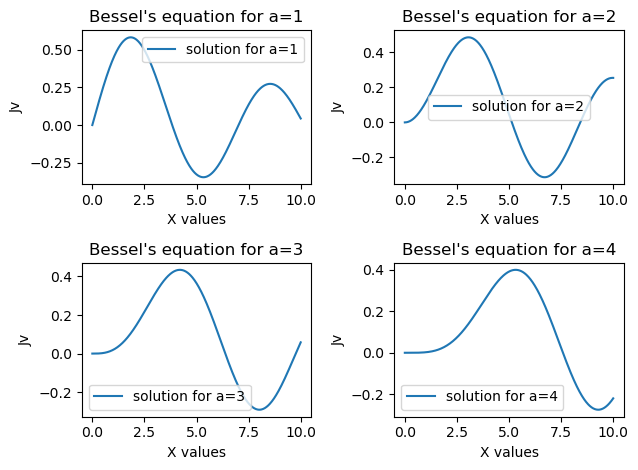

In [8]:
from scipy.special import jv
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 2) #creating the 2x2 mosaic 

axesf=ax.flatten() #flattening teh axes to make them usable

a=[1, 2, 3, 4] #defining teh values of a 
x=np.linspace(0, 10, 500) #having x go from 0 to 10

i = 0 #setting the initial index number 
for val in a:
    ax_current=axesf[i] #picking the current box
    i += 1 #uppig the index
    y = jv(val, x) #applying the bessel function
    ax_current.plot(x, y, label=f"solution for a={val}") #plotting 
    ax_current.set_title(f"Bessel's equation for a={val}")
    ax_current.set_xlabel("X values")
    ax_current.set_ylabel("Jv")
    ax_current.legend()
fig.tight_layout()

plt.savefig("bessel.png", transparent=True) #saving the bessel plots

plt.show()

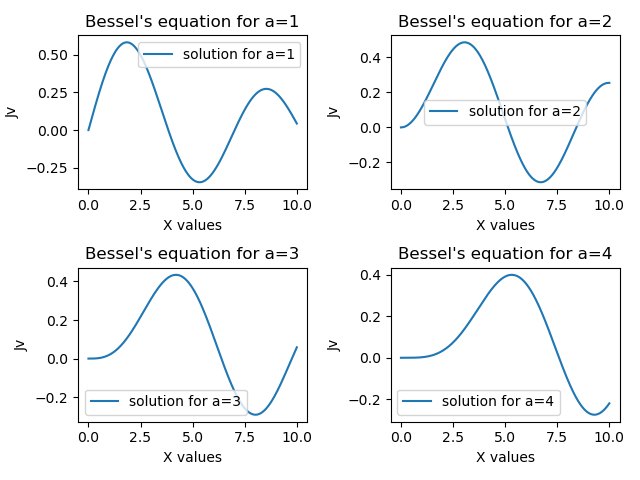

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

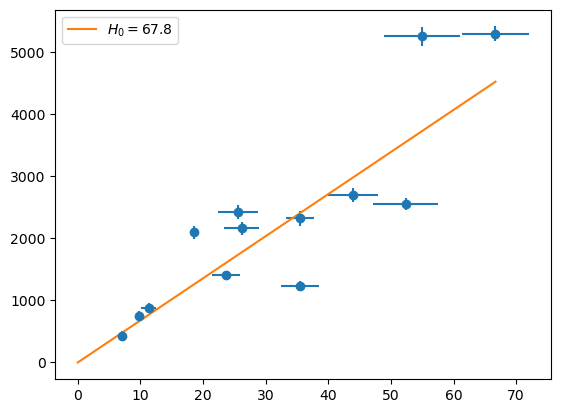

In [13]:
import matplotlib.pyplot as plt
import numpy as np

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

data2 = np.array(data).reshape(13, 4) #reshaping the data
d= data2[:, 0]; v= data2[:, 1]; errd=data2[:, 2]; errv=data2[:, 3] #unpacking the data into seperate variables

H0=67.8 #setting the Hubble cste

x=np.linspace(0, d.max(), 13) #setting the values of x so that it goes through the origin
y=H0*x #defining the slope 

fig, ax =plt.subplots() #using ax
ax.errorbar(d, v, xerr=errd, yerr=errv, fmt='o') #plotting the error bars
ax.plot(x, y, label="$H_0=67.8$") #plotting the hubble slope
ax.legend()
plt.show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
